In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_log_error
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold

In [2]:
# change file type pandas or numpy
import pandas as pd
import numpy as np

path = 'abalone.csv'

df = pd.read_csv(path)
#df = pd.read_csv(pth, index_col=0) # index_col = 0을 통해서 컬럼 갯수 제거

df.head()

,id,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [3]:
cd = df.copy()

from sklearn.model_selection import train_test_split

# df 데이터를 8:2로 나누기
df_train, df_test = train_test_split(cd, test_size=0.2, random_state=42)

# df_train과 df_test를 확인할 수 있습니다.
print("Training data size:", df_train.shape)
print("Test data size:", df_test.shape)

Training data size: (3341, 10)
Test data size: (836, 10)


In [4]:
df_train.head()

print(df_train.info())
df_train.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 3341 entries, 4038 to 860
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              3341 non-null   int64  
 1   Sex             3341 non-null   object 
 2   Length          3341 non-null   float64
 3   Diameter        3341 non-null   float64
 4   Height          3341 non-null   float64
 5   Whole_weight    3341 non-null   float64
 6   Shucked_weight  3341 non-null   float64
 7   Viscera_weight  3341 non-null   float64
 8   Shell_weight    3341 non-null   float64
 9   Rings           3341 non-null   int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 287.1+ KB
None


,id,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
count,3341.000000,3341.000000,3341.000000,3341.000000,3341.000000,3341.000000,3341.000000,3341.000000,3341.000000
mean,2116.754565,0.524964,0.408518,0.139790,0.830838,0.360561,0.180832,0.239682,9.944627
std,1202.682792,0.119137,0.098687,0.042514,0.491583,0.223018,0.109444,0.139941,3.207344
min,0.000000,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,1078.000000,0.450000,0.350000,0.115000,0.443000,0.186500,0.093000,0.130000,8.000000
50%,2121.000000,0.545000,0.425000,0.140000,0.802000,0.337000,0.171000,0.234000,9.000000
75%,3163.000000,0.615000,0.480000,0.165000,1.151000,0.503500,0.253500,0.328500,11.000000
max,4175.000000,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


In [5]:
def plot_numerics(data):
    numeric_columns = data.columns
    # Plotting histograms and box plots for each numeric column
    for column in numeric_columns:
        _, ax = plt.subplots(1,2, figsize=(16, 5))
        ax=ax.flatten()

        # Histogram
        sns.histplot(data[column], bins=50, kde=True, color='skyblue', ax=ax[0])
        ax[0].set_title(f'Histogram of {column}', fontsize=15,fontweight='bold')
        ax[0].set_xlabel(column, fontsize=12)
        ax[0].set_ylabel('Frequency', fontsize=12)

        # Box plot
        sns.boxplot(x=data[column], color='lightgreen', ax=ax[1])
        ax[1].set_title(f'Box plot of {column}', fontsize=15,fontweight='bold')
        ax[1].set_xlabel(column, fontsize=12)

        plt.tight_layout()
        plt.show()
        
def get_count_plot(cat):
    ax=sns.countplot(x=df_train[cat],
                   order=df_train[cat].value_counts(ascending=False).index);
        
    abs_values = df_train[cat].value_counts(ascending=False)
    rel_values = df_train[cat].value_counts(ascending=False, normalize=True).values * 100
    lbls = [f'{p[0]} ({p[1]:.0f}%)' for p in zip(abs_values, rel_values)]

    ax.bar_label(container=ax.containers[0], labels=lbls)
    ax.set_title("Distribution of "+cat+" Values",fontsize=16)

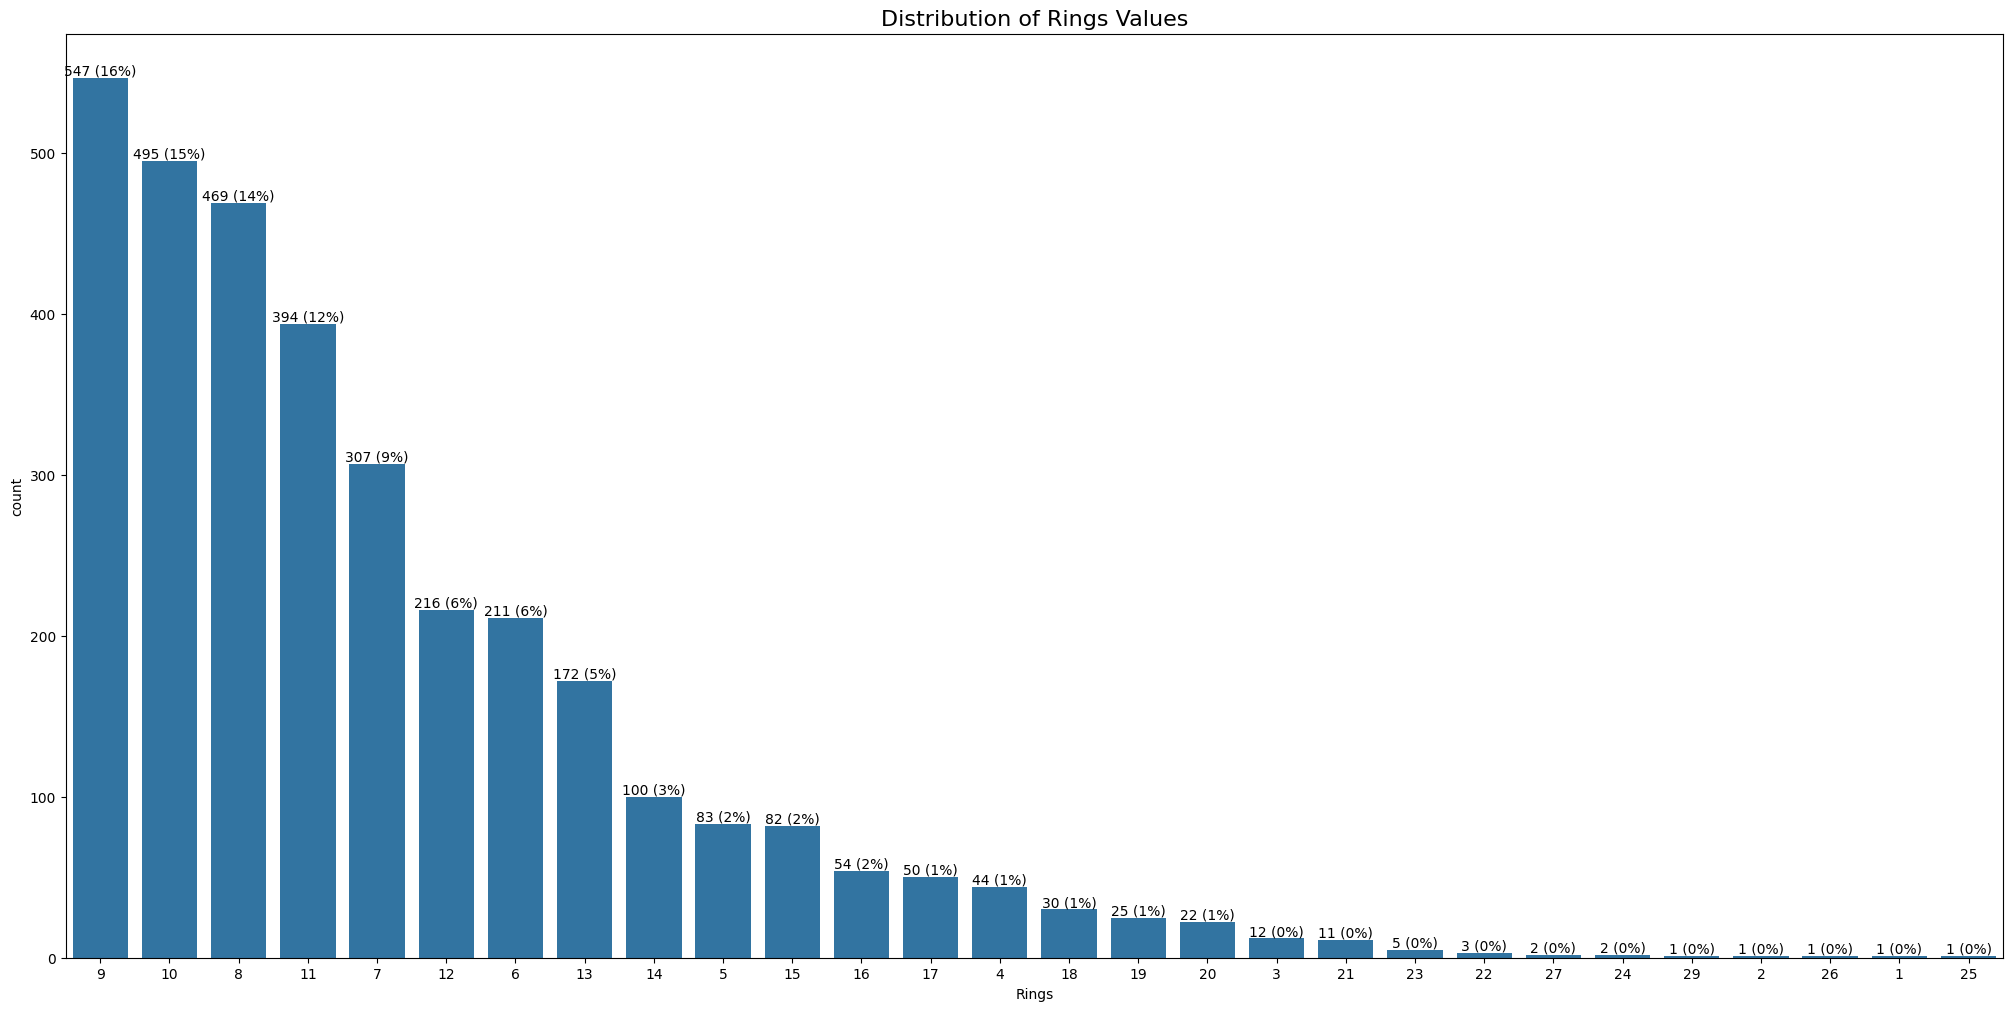

In [6]:
plt.figure(figsize=(25, 12))
get_count_plot('Rings')

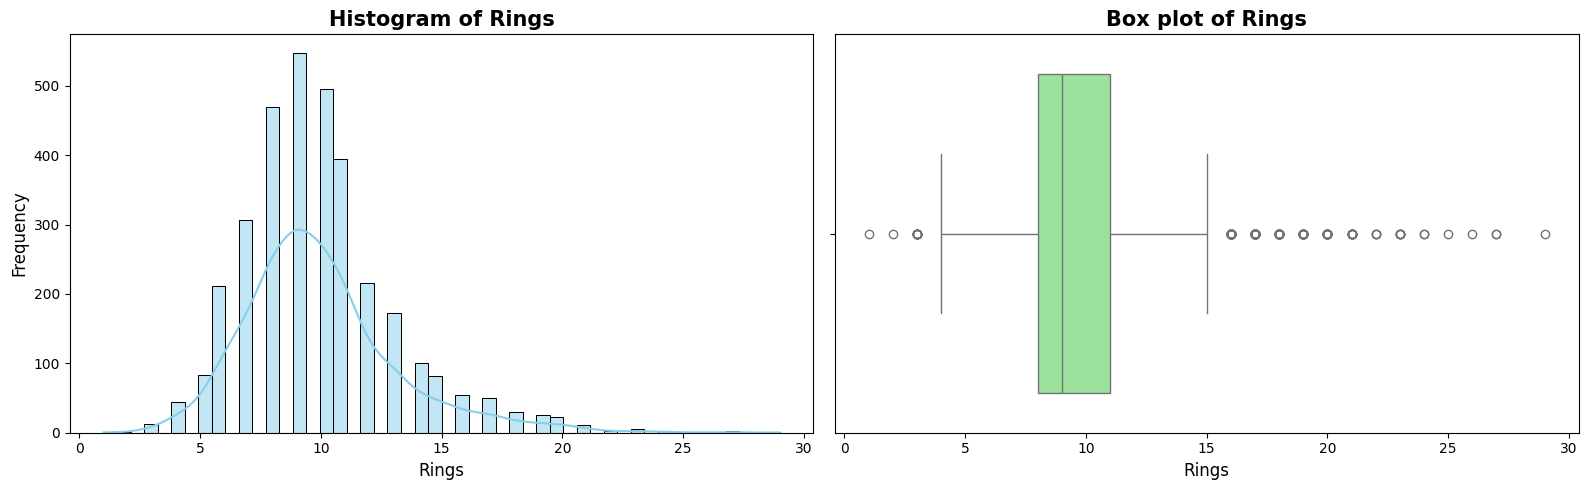

In [7]:
plot_numerics(df_train[['Rings']])

In [8]:

df_train.columns

Index(['id', 'Sex', 'Length', 'Diameter', 'Height', 'Whole_weight',
       'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Rings'],
      dtype='object')

In [9]:
df_train["Whole weight Ratio"] = df_train["Shucked_weight"] / df_train["Whole_weight"]

df_train

,id,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings,Whole weight Ratio
4038,4038,I,0.550,0.445,0.125,0.6720,0.2880,0.1365,0.210,11,0.428571
1272,1272,I,0.475,0.355,0.100,0.5035,0.2535,0.0910,0.140,8,0.503476
3384,3384,F,0.305,0.225,0.070,0.1485,0.0585,0.0335,0.045,7,0.393939
3160,3160,I,0.275,0.200,0.065,0.1165,0.0565,0.0130,0.035,7,0.484979
3894,3894,M,0.495,0.380,0.135,0.6295,0.2630,0.1425,0.215,12,0.417792
...,...,...,...,...,...,...,...,...,...,...,...
3444,3444,F,0.490,0.400,0.115,0.5690,0.2560,0.1325,0.145,9,0.449912
466,466,F,0.670,0.550,0.190,1.3905,0.5425,0.3035,0.400,12,0.390147
3092,3092,M,0.510,0.395,0.125,0.5805,0.2440,0.1335,0.188,11,0.420327
3772,3772,M,0.575,0.465,0.120,1.0535,0.5160,0.2185,0.235,9,0.489796


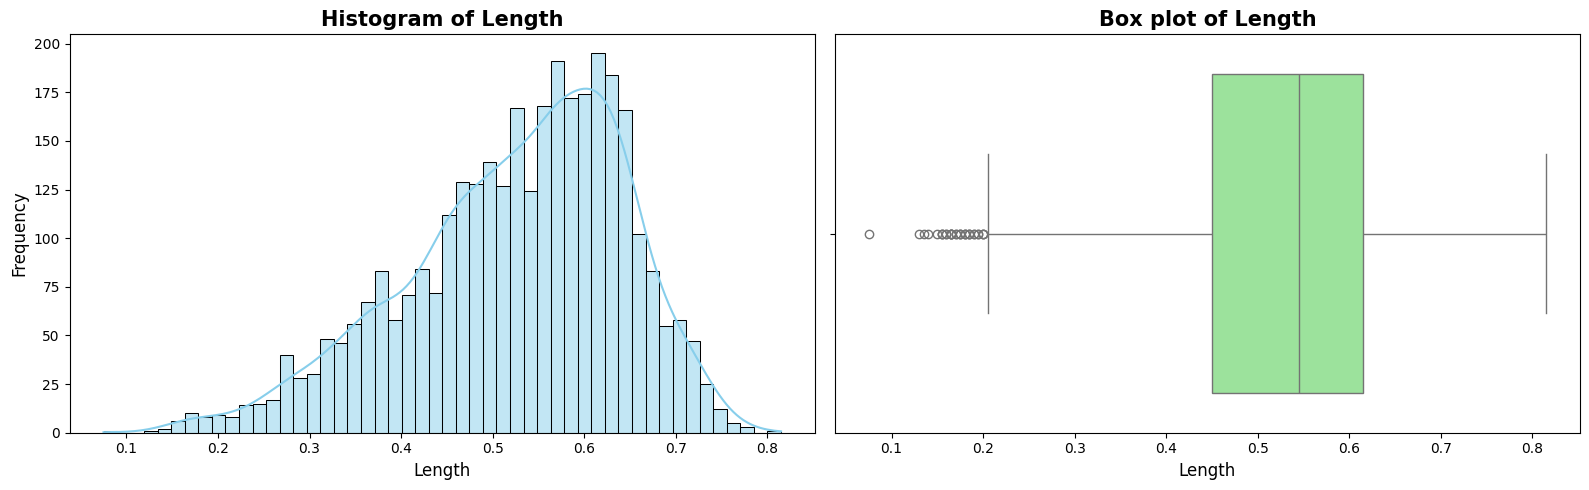

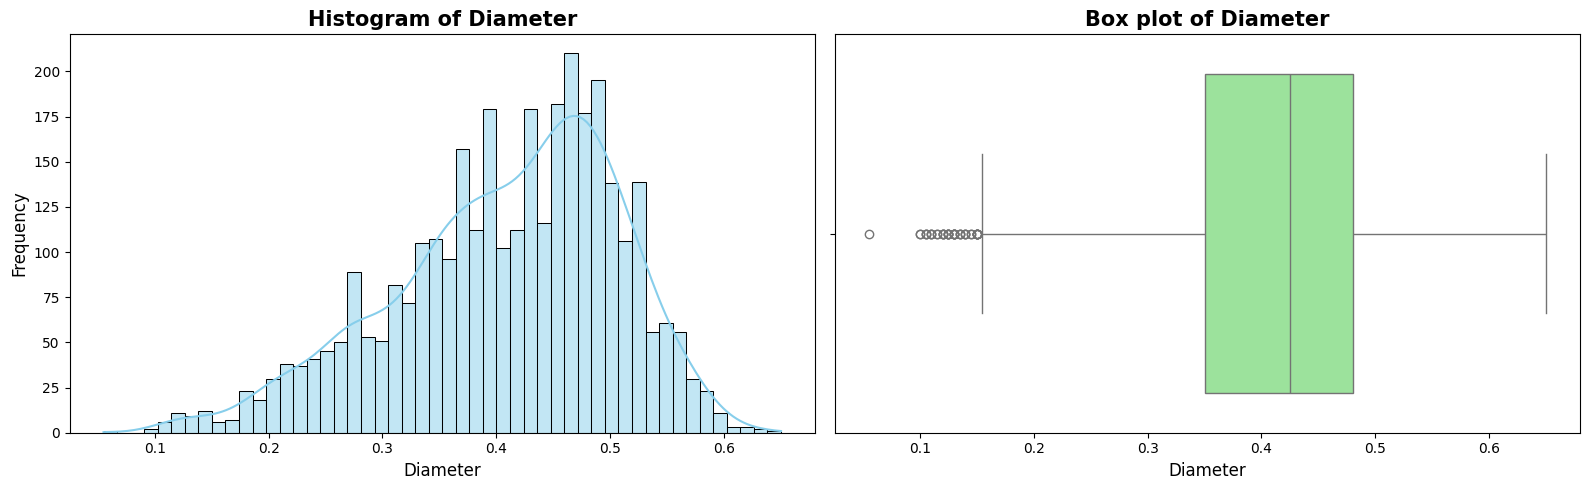

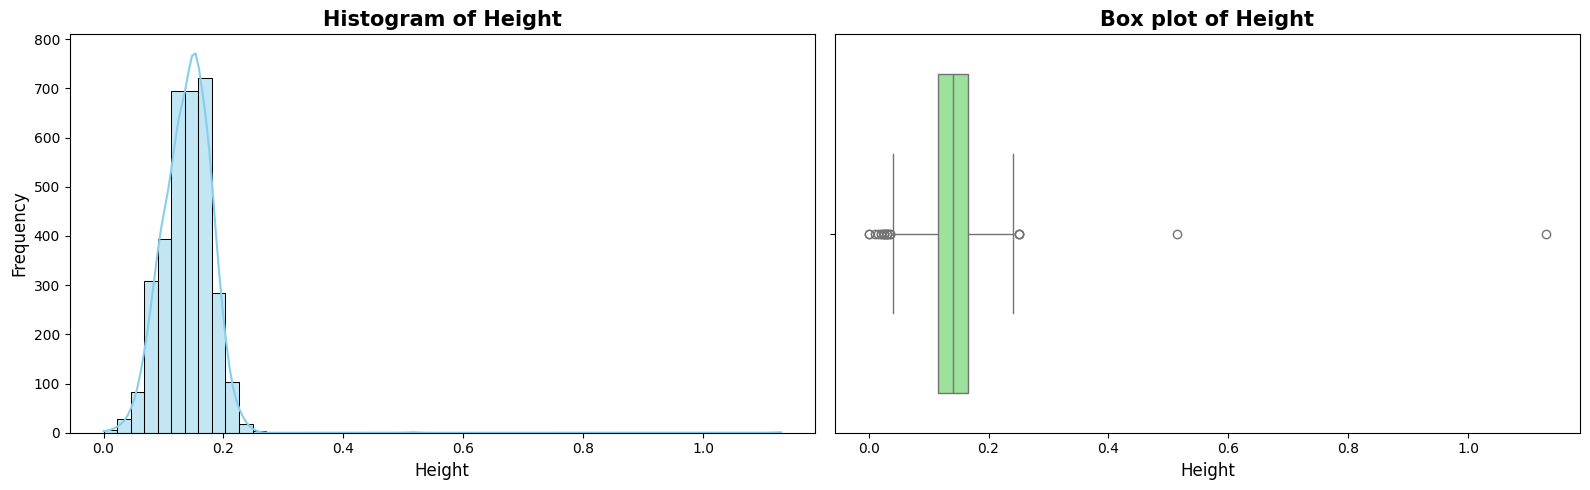

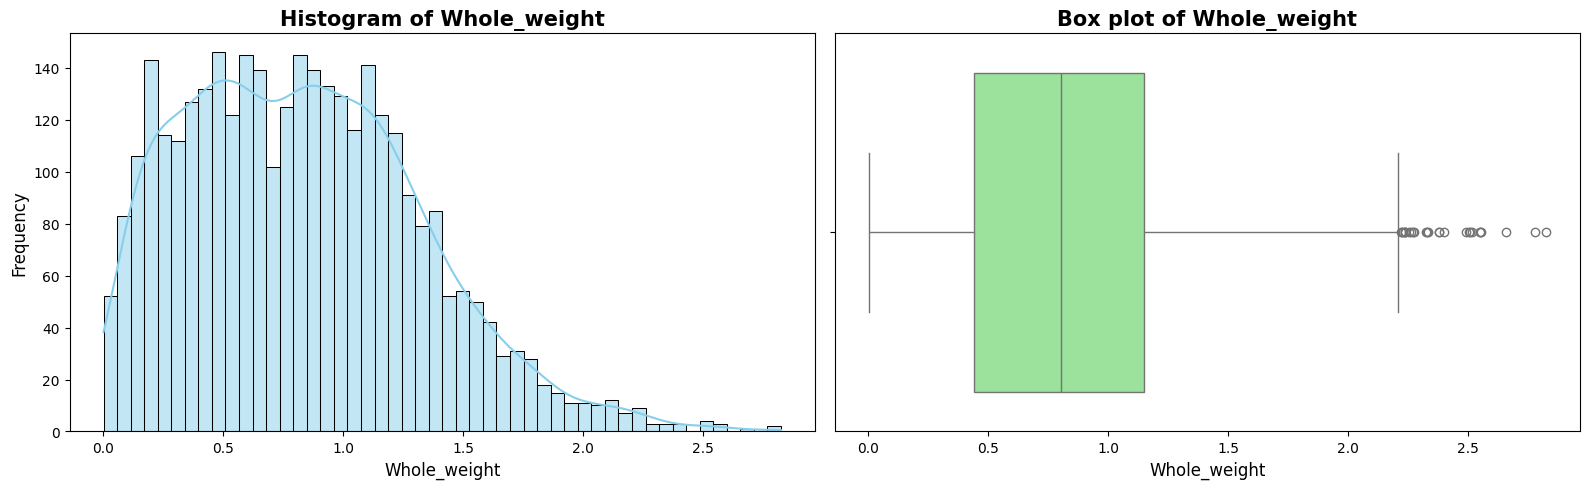

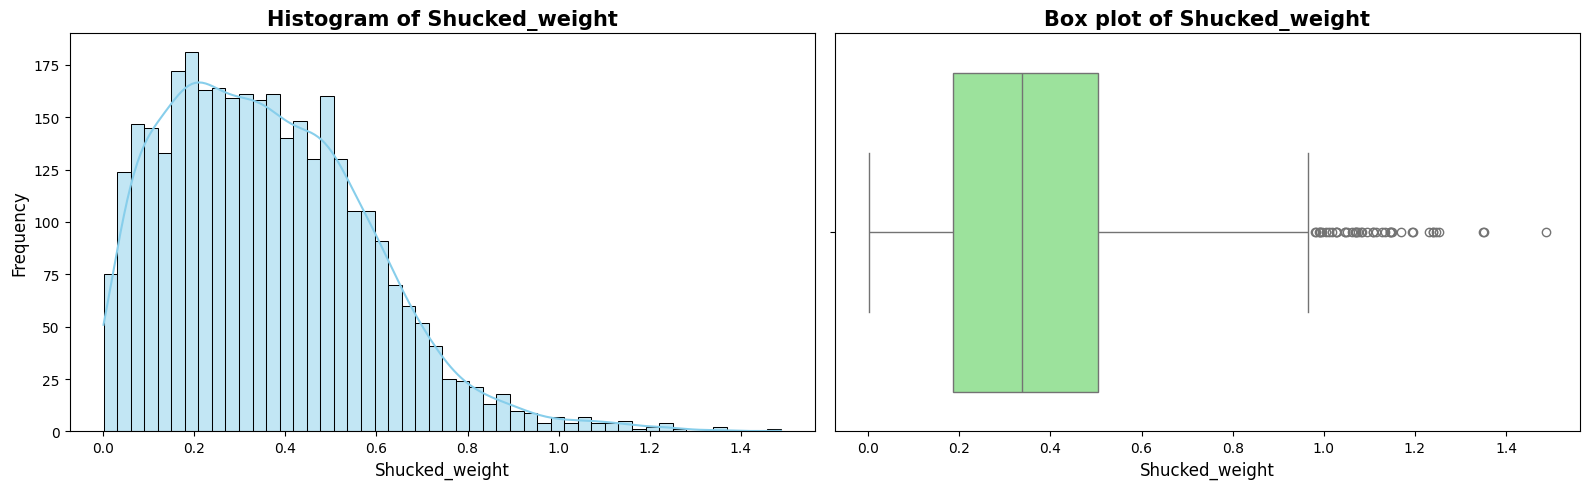

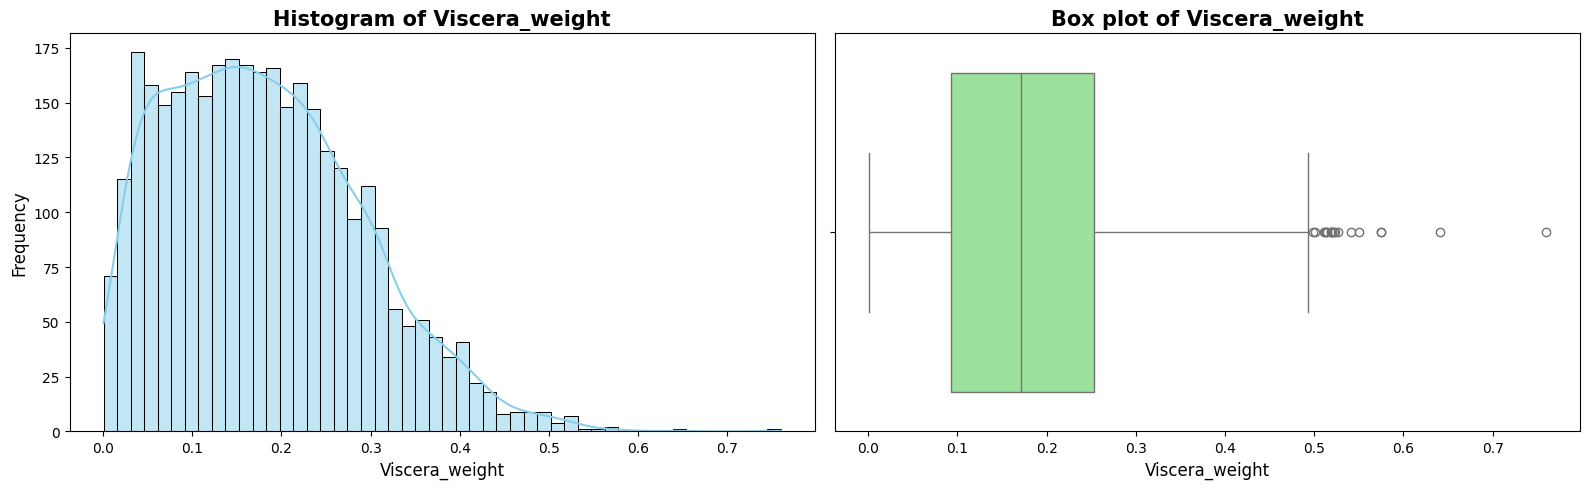

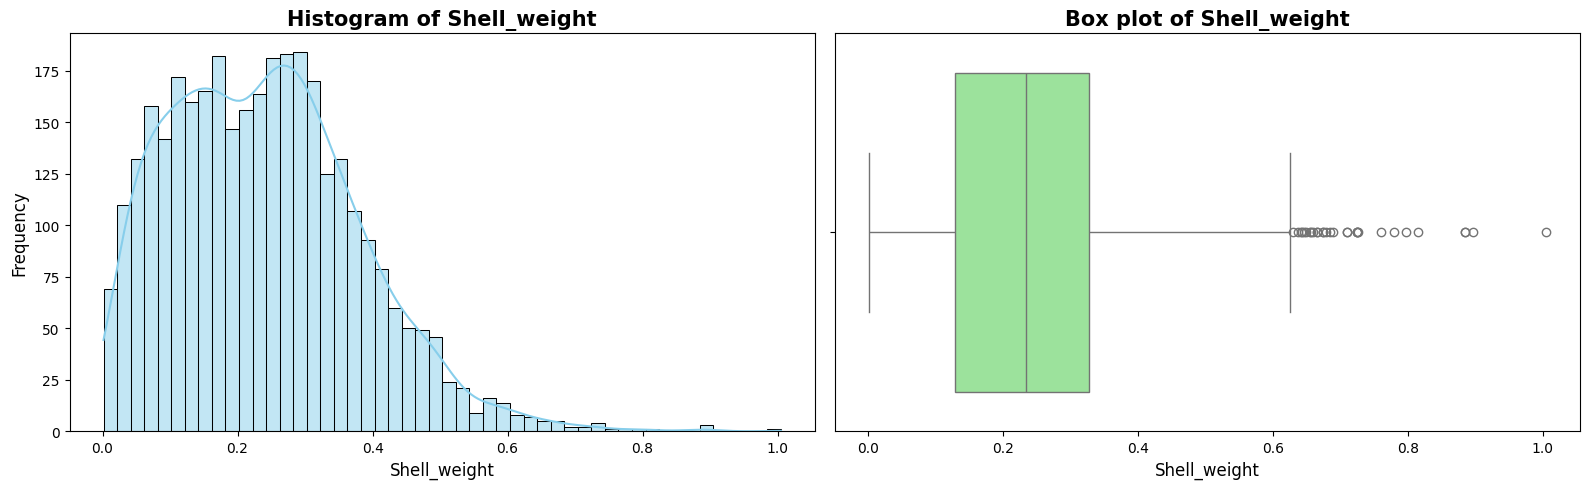

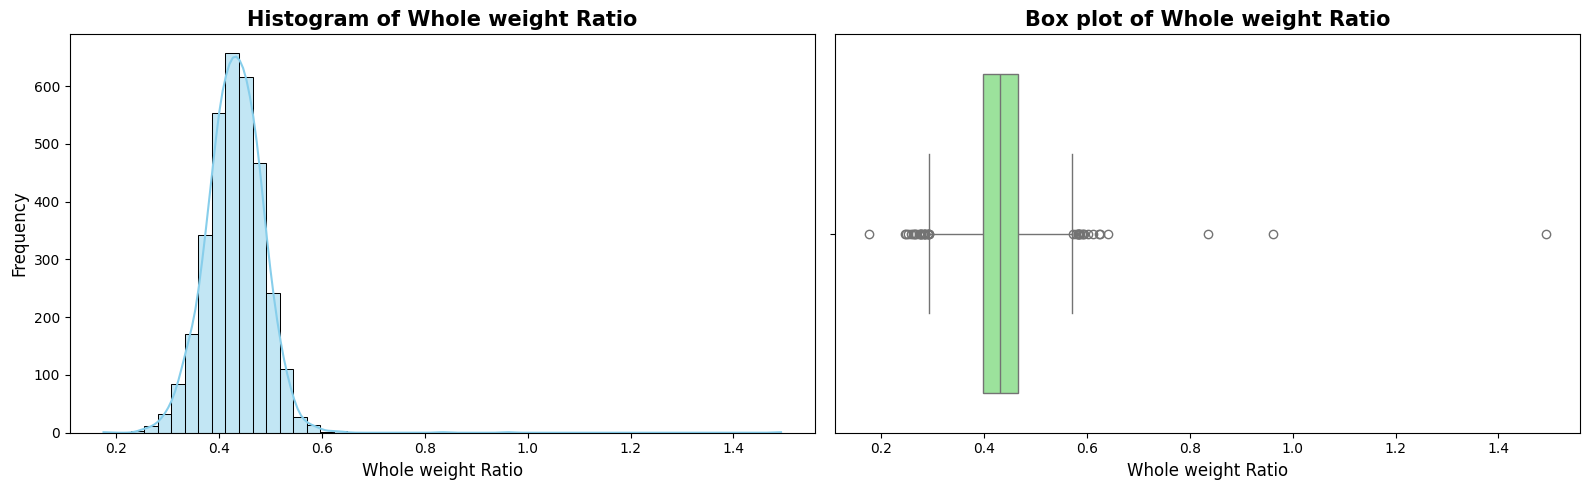

In [10]:

cat_cols=['Sex']
num_cols=['Length', 'Diameter', 'Height', 
             'Whole_weight','Shucked_weight', 
             'Viscera_weight', 'Shell_weight', "Whole weight Ratio"]

plot_numerics(df_train[num_cols])

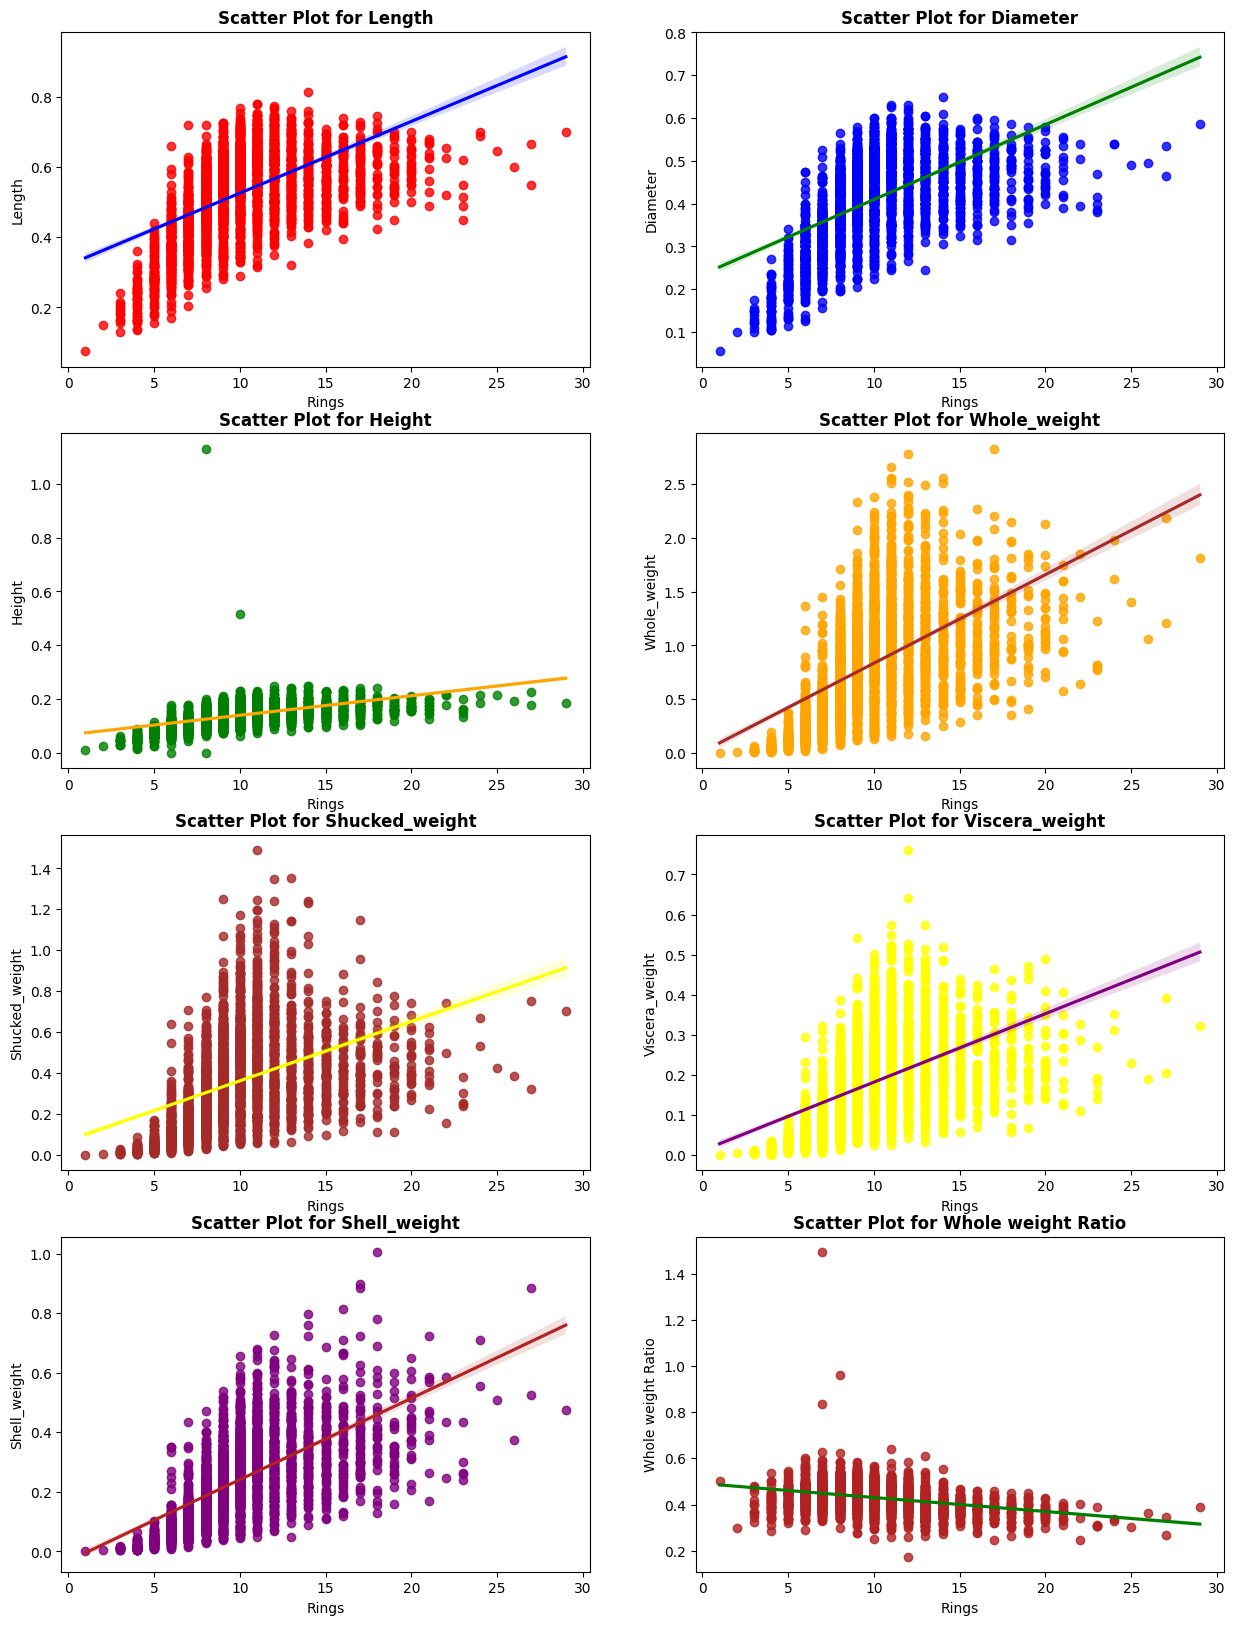

In [11]:
# Determine the size of the grid
n_cols = 2  # Number of columns in the subplot grid
n_rows = int(np.ceil(len(num_cols) / n_cols))  # Calculate the number of rows needed
#
fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axs = axs.flatten() if n_rows > 1 else [axs]
#
colors=['red','blue','green','orange','brown','yellow','purple','firebrick','green']
for i, ncol in enumerate(num_cols):
    sns.regplot(data=df_train, x="Rings", y=ncol, ax=axs[i],
                color=colors[i],line_kws=dict(color=colors[i+1]))
    axs[i].set_title(f'Scatter Plot for {ncol}',fontweight='bold')

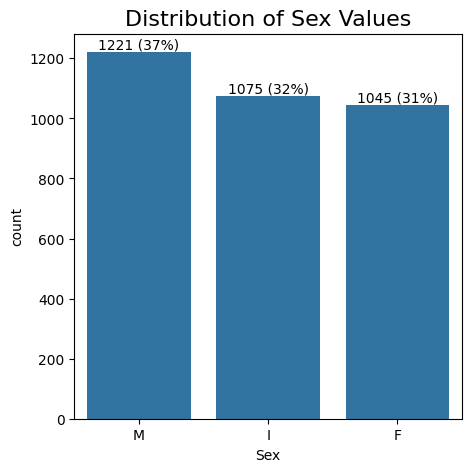

In [12]:
plt.figure(figsize=(5, 5))
get_count_plot('Sex')

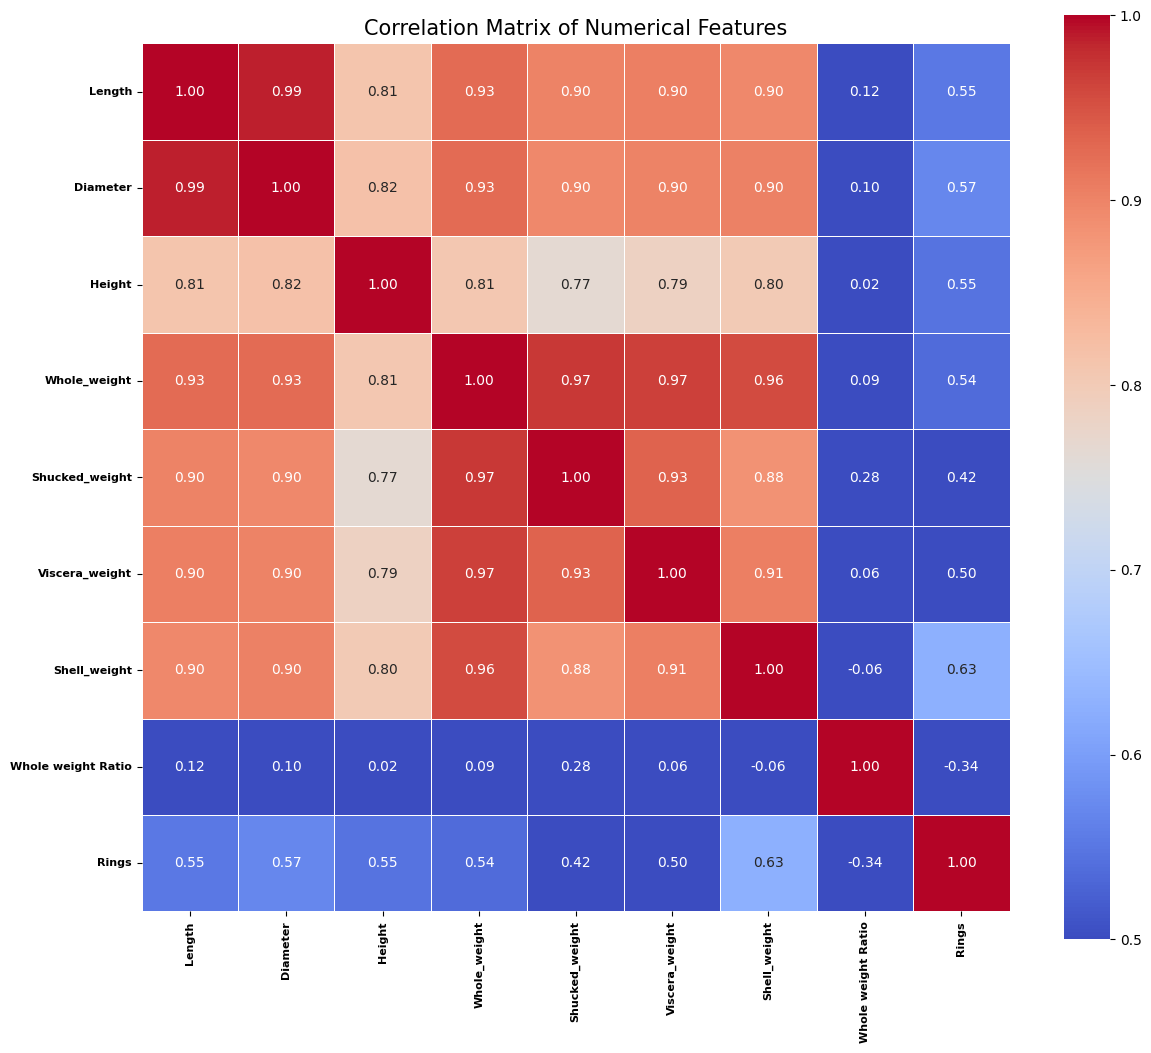

In [13]:
corr_matrix = df_train[num_cols+['Rings']].corr()
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, vmax=1, vmin=0.5, center=0.75,annot=True, fmt=".2f", square=True, 
            linewidths=.5, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features', fontsize=15)
plt.xticks(fontsize=8,fontweight='bold')
plt.yticks(fontsize=8,fontweight='bold')
plt.show()

In [14]:

num_cols=['Length','Diameter','Height',"Whole weight Ratio"]

def getFeats(df):
    
    df["Whole weight Ratio"]=df["Shucked_weight"]/df["Whole_weight"]
    df["Shell_weight"]=np.log(0.00001+df["Shell_weight"])
    df["Whole_weight"]=np.log(0.00001+df["Whole_weight"])
    df["Shucked_weight"]=np.log(0.00001+df["Shucked_weight"])
    df["Viscera_weight"]=np.log(0.00001+df["Viscera_weight"])
    
    sex_dict={'I':0,'M':1,'F':2}
    df['Sex']=df['Sex'].map(sex_dict)
    
    scaler = StandardScaler()
    df[num_cols] = scaler.fit_transform(df[num_cols])
    
    return df

df_train['typ']=0
df_test['typ']=1
#
df_all=pd.concat([df_train,df_test],axis=0)
df_all=getFeats(df_all)
df_all.head()

,id,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings,Whole weight Ratio,typ
4038,4038,0,0.216591,0.374075,-0.347099,-0.397482,-1.244760,-1.991357,-1.560600,11,-0.036338,0
1272,1272,0,-0.408000,-0.532927,-0.944870,-0.686152,-1.372352,-2.396786,-1.966041,8,0.671962,0
3384,3384,2,-1.823741,-1.843041,-1.662195,-1.907103,-2.838558,-3.395911,-3.100871,7,-0.363821,0
3160,3160,0,-2.073577,-2.094986,-1.781749,-2.149778,-2.873338,-4.342037,-3.352122,7,0.497052,0
3894,3894,1,-0.241443,-0.280982,-0.107991,-0.462814,-1.335563,-1.948343,-1.537071,12,-0.138270,0


In [15]:
df_all['Rings'].value_counts()

Rings
9     689
10    634
8     568
11    487
7     391
12    267
6     259
13    203
14    126
5     115
15    103
16     67
17     58
4      57
18     42
19     32
20     26
3      15
21     14
23      9
22      6
27      2
24      2
29      1
2       1
26      1
1       1
25      1
Name: count, dtype: int64

In [16]:
from sklearn.preprocessing import LabelEncoder

# LabelEncoder를 사용하여 숫자로 인코딩
label_encoder = LabelEncoder()
df_all['Rings'] = label_encoder.fit_transform(df_all['Rings'])


df_all['Rings'].value_counts()

Rings
8     689
9     634
7     568
10    487
6     391
11    267
5     259
12    203
13    126
4     115
14    103
15     67
16     58
3      57
17     42
18     32
19     26
2      15
20     14
22      9
21      6
26      2
23      2
27      1
1       1
25      1
0       1
24      1
Name: count, dtype: int64

In [17]:
# 필요한 라이브러리 임포트
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# 데이터 준비
df_train = df_all[df_all['typ'] == 0]
df_test = df_all[df_all['typ'] == 1]

# 피처와 타겟 설정
X_train = df_train.drop(['id', 'Rings', 'typ'], axis=1)
y_train = df_train['Rings']
X_test = df_test.drop(['id', 'Rings', 'typ'], axis=1)
y_test = df_test['Rings']

# 훈련과 검증 데이터로 분리 (옵션)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [18]:
# RandomForestClassifier 모델 생성
rf = RandomForestClassifier(random_state=42)

# 하이퍼파라미터 그리드 설정
param_grid = {
    'n_estimators': [100, 200, 500],        # 트리의 개수
    'max_depth': [None, 10, 20, 30],        # 트리의 최대 깊이
    'min_samples_split': [2, 5, 10],        # 내부 노드를 분할하는 데 필요한 최소 샘플 수
    'min_samples_leaf': [1, 2, 4],          # 리프 노드에 있어야 하는 최소 샘플 수
    'max_features': ['auto', 'sqrt', 'log2'], # 각 트리에서 사용할 피처의 수
    'bootstrap': [True, False]              # 배깅 샘플링 여부
}

# GridSearchCV를 사용한 하이퍼파라미터 튜닝
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                           scoring='accuracy', cv=3, verbose=1, n_jobs=-1)

# 모델 학습
grid_search.fit(X_train, y_train)

# 최적 하이퍼파라미터 출력
print(f"Best Hyperparameters: {grid_search.best_params_}")

Fitting 3 folds for each of 648 candidates, totalling 1944 fits
Best Hyperparameters: {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}


In [20]:
# 최적의 모델로 테스트 데이터 예측
y_pred = grid_search.predict(X_test)

# 정확도 평가
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

# 추가 평가 지표 출력 (classification report)
print(classification_report(y_test, y_pred))

Accuracy: 26.67%
              precision    recall  f1-score   support

           2       0.00      0.00      0.00         3
           3       0.35      0.62      0.44        13
           4       0.43      0.28      0.34        32
           5       0.41      0.31      0.35        48
           6       0.38      0.39      0.39        84
           7       0.35      0.42      0.39        99
           8       0.28      0.31      0.29       142
           9       0.22      0.26      0.24       139
          10       0.22      0.28      0.25        93
          11       0.09      0.04      0.05        51
          12       0.07      0.13      0.09        31
          13       0.20      0.04      0.06        26
          14       0.20      0.05      0.08        21
          15       0.14      0.08      0.10        13
          16       0.33      0.12      0.18         8
          17       0.00      0.00      0.00        12
          18       0.00      0.00      0.00         7
          

In [22]:
rd = df.copy()

# 범주형 인코딩
rd['Sex'] = LabelEncoder().fit_transform(rd['Sex'])

# 입력과 타겟 분리
X = rd.drop('Rings', axis=1).values
y = rd['Rings'].values.astype(np.float32)

# 정규화
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [23]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim

# TensorDataset으로 래핑
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)


In [27]:
# 회귀 모델 정의
class RegressionModel(nn.Module):
    def __init__(self):
        super(RegressionModel, self).__init__()
        self.model = nn.Sequential(
            #nn.Linear(8, 64),
            nn.Linear(9, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = RegressionModel().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [28]:
# 학습 루프
model.train()
for epoch in range(50):
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader):.4f}")

Epoch 1, Loss: 61.1722
Epoch 2, Loss: 13.5311
Epoch 3, Loss: 7.3571
Epoch 4, Loss: 6.2708
Epoch 5, Loss: 5.8464
Epoch 6, Loss: 5.5728
Epoch 7, Loss: 5.2839
Epoch 8, Loss: 5.1522
Epoch 9, Loss: 4.9824
Epoch 10, Loss: 4.9170
Epoch 11, Loss: 4.7756
Epoch 12, Loss: 4.7145
Epoch 13, Loss: 4.6621
Epoch 14, Loss: 4.6113
Epoch 15, Loss: 4.5723
Epoch 16, Loss: 4.5424
Epoch 17, Loss: 4.5320
Epoch 18, Loss: 4.4586
Epoch 19, Loss: 4.4205
Epoch 20, Loss: 4.4173
Epoch 21, Loss: 4.3701
Epoch 22, Loss: 4.3632
Epoch 23, Loss: 4.3500
Epoch 24, Loss: 4.3357
Epoch 25, Loss: 4.3192
Epoch 26, Loss: 4.3094
Epoch 27, Loss: 4.3035
Epoch 28, Loss: 4.3134
Epoch 29, Loss: 4.2555
Epoch 30, Loss: 4.2980
Epoch 31, Loss: 4.2617
Epoch 32, Loss: 4.2434
Epoch 33, Loss: 4.2420
Epoch 34, Loss: 4.2606
Epoch 35, Loss: 4.2651
Epoch 36, Loss: 4.1954
Epoch 37, Loss: 4.2084
Epoch 38, Loss: 4.2164
Epoch 39, Loss: 4.1558
Epoch 40, Loss: 4.1708
Epoch 41, Loss: 4.1649
Epoch 42, Loss: 4.1402
Epoch 43, Loss: 4.1227
Epoch 44, Loss: 4.

In [29]:
# 평가
model.eval()
preds, actuals = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch).cpu().numpy()
        preds.extend(outputs)
        actuals.extend(y_batch.numpy())

mse = mean_squared_error(actuals, preds)
print(f"Test MSE: {mse:.4f}")

Test MSE: 4.2706
